# Feature Engineering & Model Selection — April 23
**Pipeline:** 377 poly features → top-20 selection → default vs tuned RF & XGB → OOF stacking

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import balanced_accuracy_score
from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import DropConstantFeatures
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

## 1. Load and Preprocess Data

In [25]:
adult = pd.read_csv("adult.csv")

# encode target
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)

# drop fnlwgt — not predictive; errors='ignore' makes the cell safe to re-run
adult.drop(columns=["fnlwgt"], inplace=True, errors='ignore')

# gender to binary
adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)

# replace ? with NaN then impute
adult.replace("?", np.nan, inplace=True)

for col in adult.columns:
    if adult[col].dtype == "object":
        adult[col] = adult[col].fillna("unknown")
    elif adult[col].dtype == "string":
        adult[col] = adult[col].fillna("unknown")
    else:
        adult[col] = adult[col].fillna(adult[col].median())

adult.head()

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,unknown,Some-college,10,Never-married,unknown,Own-child,White,0,0,0,30,United-States,0


## 2. Feature Engineering Pipeline (feature-engine)

In [26]:
df_fe = adult.copy()

X = df_fe.drop("income", axis=1)
y = df_fe["income"]

X_train_fe, X_test_fe, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_cols = X_train_fe.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()

# collapse rare categories
rare_encoder = RareLabelEncoder(tol=0.01, variables=cat_cols)
X_train_fe = rare_encoder.fit_transform(X_train_fe)
X_test_fe  = rare_encoder.transform(X_test_fe)

# frequency-encode categoricals
freq_encoder = CountFrequencyEncoder(variables=cat_cols, encoding_method="frequency")
X_train_fe = freq_encoder.fit_transform(X_train_fe)
X_test_fe  = freq_encoder.transform(X_test_fe)

# equal-frequency discretise numeric (skip binary and skewed capital columns)
disc_vars = [c for c in num_cols if c not in ["gender", "capital-gain", "capital-loss"]]
disc = EqualFrequencyDiscretiser(q=5, variables=disc_vars)
X_train_fe = disc.fit_transform(X_train_fe)
X_test_fe  = disc.transform(X_test_fe)

# drop any constants created by binning
const_drop = DropConstantFeatures()
X_train_fe = const_drop.fit_transform(X_train_fe)
X_test_fe  = const_drop.transform(X_test_fe)

print("Feature-engineered train shape:", X_train_fe.shape)
print("Feature-engineered test shape: ", X_test_fe.shape)
X_train_fe.head()

Feature-engineered train shape: (39073, 13)
Feature-engineered test shape:  (9769, 13)


,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
34342,4,0.693727,0.324751,0,0.330945,0.042664,0.258618,0.85609,1,0,0,0,0.898344
18559,0,0.693727,0.028613,0,0.330945,0.113122,0.031352,0.85609,0,0,0,0,0.898344
12477,1,0.693727,0.324751,0,0.456632,0.101144,0.402580,0.85609,1,0,0,1,0.064699
560,3,0.693727,0.324751,0,0.031684,0.115067,0.105239,0.09513,0,0,0,1,0.898344
3427,1,0.693727,0.164257,2,0.456632,0.125278,0.402580,0.85609,1,0,0,1,0.898344


## 3. Polynomial Feature Expansion (→ 377 features)

In [27]:
poly = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)

X_train_poly = poly.fit_transform(X_train_fe)
X_test_poly  = poly.transform(X_test_fe)

poly_names = poly.get_feature_names_out(X_train_fe.columns)

X_train_poly_df = pd.DataFrame(X_train_poly, columns=poly_names, index=X_train_fe.index)
X_test_poly_df  = pd.DataFrame(X_test_poly,  columns=poly_names, index=X_test_fe.index)

print("Expanded train shape:", X_train_poly_df.shape)
print("Expanded test shape: ", X_test_poly_df.shape)

Expanded train shape: (39073, 377)
Expanded test shape:  (9769, 377)


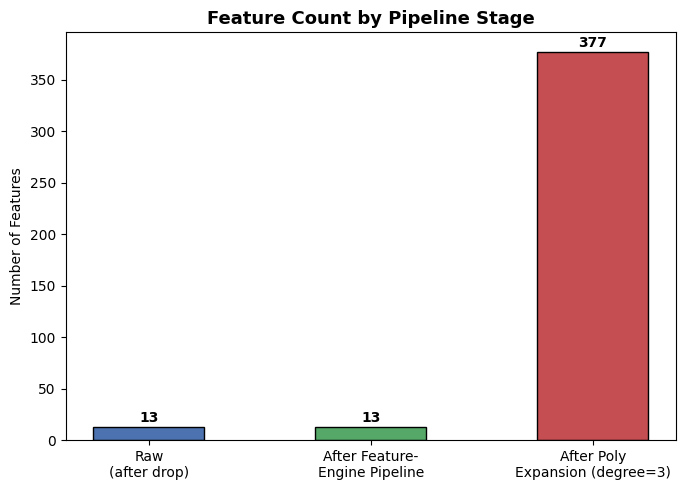

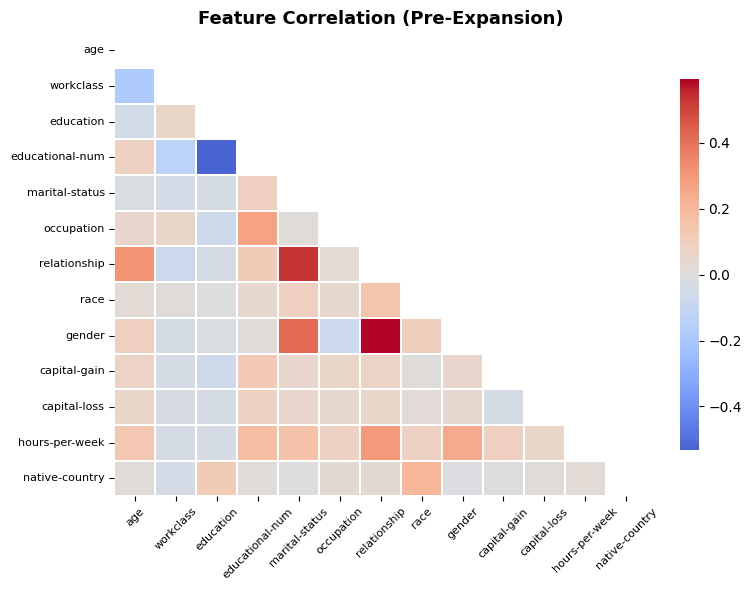

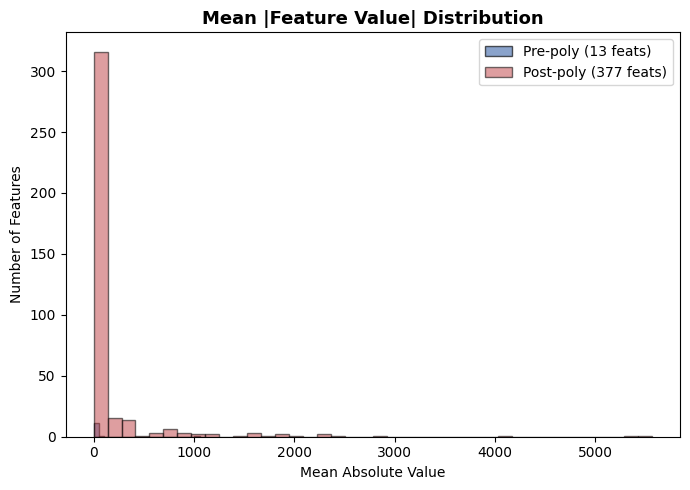

In [28]:
# --- Plot 1: Feature count at each pipeline stage ---
fig, ax = plt.subplots(figsize=(7, 5))
stages = ['Raw\n(after drop)', 'After Feature-\nEngine Pipeline', 'After Poly\nExpansion (degree=3)']
counts = [X_train_fe.shape[1], X_train_fe.shape[1], X_train_poly_df.shape[1]]
bars = ax.bar(stages, counts, color=['#4C72B0', '#55A868', '#C44E52'], edgecolor='black', width=0.5)
ax.set_title('Feature Count by Pipeline Stage', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Features')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, str(count),
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# --- Plot 2: Correlation heatmap of pre-poly features ---
fig, ax = plt.subplots(figsize=(8, 6))
corr = X_train_fe.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation (Pre-Expansion)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

# --- Plot 3: Distribution of mean absolute values — original vs poly features ---
fig, ax = plt.subplots(figsize=(7, 5))
orig_means = np.abs(X_train_fe.values).mean(axis=0)
poly_means = np.abs(X_train_poly_df.values).mean(axis=0)
ax.hist(orig_means, bins=20, alpha=0.65, label=f'Pre-poly ({len(orig_means)} feats)',
        color='#4C72B0', edgecolor='black')
ax.hist(poly_means, bins=40, alpha=0.55, label=f'Post-poly ({len(poly_means)} feats)',
        color='#C44E52', edgecolor='black')
ax.set_title('Mean |Feature Value| Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Absolute Value')
ax.set_ylabel('Number of Features')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 4. Score All 377 Features (RF + XGB Importance + Permutation Importance)

In [29]:
# class-imbalance weight for XGB
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
spw = neg / pos

# fast models (100 trees) just to rank features — not the final models
rf_score = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf_score.fit(X_train_poly_df, y_train)

xgb_score = XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', n_estimators=100, random_state=42)
xgb_score.fit(X_train_poly_df, y_train)

print("Scoring models trained on all 377 features.")

Scoring models trained on all 377 features.


In [30]:
# subsample test set for faster permutation importance
sub_idx = X_test_poly_df.sample(n=2000, random_state=42).index
X_sub = X_test_poly_df.loc[sub_idx]
y_sub = y_test.loc[sub_idx]

rf_perm  = permutation_importance(rf_score,  X_sub, y_sub, n_repeats=5, random_state=42)
xgb_perm = permutation_importance(xgb_score, X_sub, y_sub, n_repeats=5, random_state=42)

rf_perm_df = pd.DataFrame({
    'feature': X_test_poly_df.columns,
    'importance_mean': rf_perm.importances_mean
})

xgb_perm_df = pd.DataFrame({
    'feature': X_test_poly_df.columns,
    'importance_mean': xgb_perm.importances_mean
})

print("Permutation importances computed.")

Permutation importances computed.


## 5. Averaged Rank Selection — Reduce to Top 20 Features

In [31]:
# Random Forest: average feature importance rank and permutation importance rank
rf_feat_df = pd.DataFrame({
    'feature': X_train_poly_df.columns,
    'feat_importance': rf_score.feature_importances_
})
rf_feat_df['rank_feat'] = rf_feat_df['feat_importance'].rank(ascending=False)
rf_perm_df['rank_perm'] = rf_perm_df['importance_mean'].rank(ascending=False)

rf_combined = rf_feat_df.merge(rf_perm_df[['feature', 'rank_perm']], on='feature')
rf_combined['rank_avg'] = (rf_combined['rank_feat'] + rf_combined['rank_perm']) / 2
rf_combined = rf_combined.sort_values('rank_avg').reset_index(drop=True)

print("=== Top 20 RF Ranks ===")
rf_combined.head(20)

=== Top 20 RF Ranks ===


,feature,feat_importance,rank_feat,rank_perm,rank_avg
0,capital-gain,0.006321,31.0,4.0,17.50
1,relationship capital-gain,0.004068,59.0,27.0,43.00
2,race capital-gain native-country,0.003503,76.0,19.5,47.75
3,age capital-gain,0.002701,105.0,12.5,58.75
4,marital-status capital-gain,0.002474,120.0,15.5,67.75
5,marital-status race capital-gain,0.002342,127.0,15.5,71.25
6,relationship capital-gain native-country,0.002365,126.0,27.0,76.50
7,marital-status relationship capital-gain,0.002010,147.0,6.5,76.75
8,marital-status occupation capital-gain,0.002054,145.0,27.0,86.00
9,capital-gain native-country,0.005813,40.0,139.0,89.50


In [32]:
# XGBoost: average feature importance rank and permutation importance rank
xgb_feat_df = pd.DataFrame({
    'feature': X_train_poly_df.columns,
    'feat_importance': xgb_score.feature_importances_
})
xgb_feat_df['rank_feat'] = xgb_feat_df['feat_importance'].rank(ascending=False)
xgb_perm_df['rank_perm'] = xgb_perm_df['importance_mean'].rank(ascending=False)

xgb_combined = xgb_feat_df.merge(xgb_perm_df[['feature', 'rank_perm']], on='feature')
xgb_combined['rank_avg'] = (xgb_combined['rank_feat'] + xgb_combined['rank_perm']) / 2
xgb_combined = xgb_combined.sort_values('rank_avg').reset_index(drop=True)

print("=== Top 20 XGB Ranks ===")
xgb_combined.head(20)

=== Top 20 XGB Ranks ===


,feature,feat_importance,rank_feat,rank_perm,rank_avg
0,marital-status,0.260233,1.0,2.0,1.50
1,capital-gain,0.021948,4.0,1.0,2.50
2,age educational-num hours-per-week,0.065549,3.0,16.0,9.50
3,age educational-num occupation,0.013850,7.0,18.5,12.75
4,capital-loss,0.006143,22.0,5.0,13.50
5,educational-num occupation,0.017588,5.0,26.5,15.75
6,relationship capital-gain,0.005811,24.0,8.0,16.00
7,marital-status capital-gain,0.004497,29.0,3.0,16.00
8,educational-num relationship hours-per-week,0.010310,11.0,26.5,18.75
9,educational-num hours-per-week,0.004521,28.0,13.0,20.50


In [33]:
# Combined RF + XGB cross-model rank → select top 20
cross_rank = rf_combined[['feature', 'rank_avg']].rename(columns={'rank_avg': 'rf_rank'}).merge(
    xgb_combined[['feature', 'rank_avg']].rename(columns={'rank_avg': 'xgb_rank'}),
    on='feature'
)
cross_rank['combined_rank'] = (cross_rank['rf_rank'] + cross_rank['xgb_rank']) / 2
cross_rank = cross_rank.sort_values('combined_rank').reset_index(drop=True)

top20_features = cross_rank.head(20)['feature'].tolist()

print("=== Top 20 Combined Ranks ===")
cross_rank.head(20)

=== Top 20 Combined Ranks ===


,feature,rf_rank,xgb_rank,combined_rank
0,capital-gain,17.50,2.50,10.000
1,relationship capital-gain,43.00,16.00,29.500
2,marital-status capital-gain,67.75,16.00,41.875
3,educational-num occupation,109.75,15.75,62.750
4,marital-status capital-loss,135.00,21.00,78.000
5,educational-num occupation race,133.00,28.50,80.750
6,educational-num relationship hours-per-week,152.75,18.75,85.750
7,educational-num native-country,155.50,25.50,90.500
8,workclass education educational-num,108.75,76.50,92.625
9,marital-status,188.00,1.50,94.750


In [34]:
# create reduced datasets
X_train_20 = X_train_poly_df[top20_features]
X_test_20  = X_test_poly_df[top20_features]

print("Reduced train shape:", X_train_20.shape)
print("Reduced test shape: ", X_test_20.shape)

Reduced train shape: (39073, 20)
Reduced test shape:  (9769, 20)


## 6. Baseline Models (Default Parameters) on Top 20 Features

In [35]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# default Random Forest
rf_default = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_cv_default = cross_val_score(rf_default, X_train_20, y_train, cv=skf, scoring='balanced_accuracy')
rf_default.fit(X_train_20, y_train)
rf_preds_default = rf_default.predict(X_test_20)

# default XGBoost
xgb_default = XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42)
xgb_cv_default = cross_val_score(xgb_default, X_train_20, y_train, cv=skf, scoring='balanced_accuracy')
xgb_default.fit(X_train_20, y_train)
xgb_preds_default = xgb_default.predict(X_test_20)

print("=== Baseline (Default) Models — Top 20 Features ===")
print(f"RF  CV:   {rf_cv_default.mean():.4f} ± {rf_cv_default.std():.4f}")
print(f"RF  Test: {balanced_accuracy_score(y_test, rf_preds_default):.4f}")
print(f"XGB CV:   {xgb_cv_default.mean():.4f} ± {xgb_cv_default.std():.4f}")
print(f"XGB Test: {balanced_accuracy_score(y_test, xgb_preds_default):.4f}")

=== Baseline (Default) Models — Top 20 Features ===
RF  CV:   0.7960 ± 0.0045
RF  Test: 0.7954
XGB CV:   0.8317 ± 0.0030
XGB Test: 0.8271


## 7. Hyperparameter Tuning

In [36]:
# Random Forest tuning
rf_param_dist = {
    'n_estimators':     [200, 400, 600],
    'max_depth':        [None, 10, 20, 30],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2', 0.5]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=skf,
    scoring='balanced_accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train_20, y_train)

print("Best RF params:", rf_search.best_params_)
print(f"Best RF CV Balanced Accuracy: {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 10}
Best RF CV Balanced Accuracy: 0.8244


In [37]:
# XGBoost tuning
xgb_param_dist = {
    'n_estimators':      [200, 400, 600],
    'max_depth':         [3, 5, 7, 9],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'subsample':         [0.6, 0.8, 1.0],
    'colsample_bytree':  [0.6, 0.8, 1.0],
    'min_child_weight':  [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42),
    param_distributions=xgb_param_dist,
    n_iter=20,
    cv=skf,
    scoring='balanced_accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train_20, y_train)

print("Best XGB params:", xgb_search.best_params_)
print(f"Best XGB CV Balanced Accuracy: {xgb_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGB params: {'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.6}
Best XGB CV Balanced Accuracy: 0.8336


In [38]:
# evaluate tuned models on test set
rf_tuned  = rf_search.best_estimator_
xgb_tuned = xgb_search.best_estimator_

rf_tuned.fit(X_train_20, y_train)
xgb_tuned.fit(X_train_20, y_train)

rf_preds_tuned  = rf_tuned.predict(X_test_20)
xgb_preds_tuned = xgb_tuned.predict(X_test_20)

rf_cv_tuned  = cross_val_score(rf_tuned,  X_train_20, y_train, cv=skf, scoring='balanced_accuracy')
xgb_cv_tuned = cross_val_score(xgb_tuned, X_train_20, y_train, cv=skf, scoring='balanced_accuracy')

print("=== Tuned Models — Top 20 Features ===")
print(f"RF  CV:   {rf_cv_tuned.mean():.4f} ± {rf_cv_tuned.std():.4f}")
print(f"RF  Test: {balanced_accuracy_score(y_test, rf_preds_tuned):.4f}")
print(f"XGB CV:   {xgb_cv_tuned.mean():.4f} ± {xgb_cv_tuned.std():.4f}")
print(f"XGB Test: {balanced_accuracy_score(y_test, xgb_preds_tuned):.4f}")

=== Tuned Models — Top 20 Features ===
RF  CV:   0.8244 ± 0.0028
RF  Test: 0.8248
XGB CV:   0.8339 ± 0.0029
XGB Test: 0.8276


In [39]:
# default vs tuned side-by-side
print("=== Default vs Tuned ===")
header = f"{'Model':<10} {'Default CV':>12} {'Tuned CV':>10} {'Default Test':>14} {'Tuned Test':>12}"
print(header)
print("-" * len(header))
print(f"{'RF':<10} {rf_cv_default.mean():>12.4f} {rf_cv_tuned.mean():>10.4f} "
      f"{balanced_accuracy_score(y_test, rf_preds_default):>14.4f} "
      f"{balanced_accuracy_score(y_test, rf_preds_tuned):>12.4f}")
print(f"{'XGBoost':<10} {xgb_cv_default.mean():>12.4f} {xgb_cv_tuned.mean():>10.4f} "
      f"{balanced_accuracy_score(y_test, xgb_preds_default):>14.4f} "
      f"{balanced_accuracy_score(y_test, xgb_preds_tuned):>12.4f}")

=== Default vs Tuned ===
Model        Default CV   Tuned CV   Default Test   Tuned Test
--------------------------------------------------------------
RF               0.7960     0.8244         0.7954       0.8248
XGBoost          0.8317     0.8339         0.8271       0.8276


## 8. Stacking — Meta Learner with Out-of-Fold Predictions

In [40]:
# OOF Stacking: tuned RF + tuned XGB → Logistic Regression meta model

rf_oof  = np.zeros(len(X_train_20))
xgb_oof = np.zeros(len(X_train_20))

for train_idx, val_idx in skf.split(X_train_20, y_train):
    X_tr, X_val = X_train_20.iloc[train_idx], X_train_20.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]

    # clone tuned params for each fold
    rf_fold  = RandomForestClassifier(**rf_tuned.get_params())
    xgb_fold = XGBClassifier(**xgb_tuned.get_params())

    rf_fold.fit(X_tr, y_tr)
    xgb_fold.fit(X_tr, y_tr)

    rf_oof[val_idx]  = rf_fold.predict_proba(X_val)[:, 1]
    xgb_oof[val_idx] = xgb_fold.predict_proba(X_val)[:, 1]

# train meta model on OOF predictions
X_meta_train = np.column_stack((rf_oof, xgb_oof))
meta_model = LogisticRegression()
meta_model.fit(X_meta_train, y_train)

# retrain base models on full training data
rf_tuned.fit(X_train_20, y_train)
xgb_tuned.fit(X_train_20, y_train)

# generate test predictions
rf_test_proba  = rf_tuned.predict_proba(X_test_20)[:, 1]
xgb_test_proba = xgb_tuned.predict_proba(X_test_20)[:, 1]

X_meta_test = np.column_stack((rf_test_proba, xgb_test_proba))
meta_preds  = meta_model.predict(X_meta_test)

print("Stacked Model Test Balanced Accuracy:", balanced_accuracy_score(y_test, meta_preds))

Stacked Model Test Balanced Accuracy: 0.8041949436383016


## 9. Final Model Comparison

In [41]:
results = pd.DataFrame({
    'Model': [
        'RF Default (20 features)',
        'XGB Default (20 features)',
        'RF Tuned (20 features)',
        'XGB Tuned (20 features)',
        'Stacked: Tuned RF + XGB'
    ],
    'Test Balanced Accuracy': [
        balanced_accuracy_score(y_test, rf_preds_default),
        balanced_accuracy_score(y_test, xgb_preds_default),
        balanced_accuracy_score(y_test, rf_preds_tuned),
        balanced_accuracy_score(y_test, xgb_preds_tuned),
        balanced_accuracy_score(y_test, meta_preds)
    ]
})

results['Test Balanced Accuracy'] = results['Test Balanced Accuracy'].round(4)
results = results.sort_values('Test Balanced Accuracy', ascending=False).reset_index(drop=True)

print("=== Final Model Comparison ===")
print(results.to_string(index=False))

=== Final Model Comparison ===
                    Model  Test Balanced Accuracy
  XGB Tuned (20 features)                  0.8276
XGB Default (20 features)                  0.8271
   RF Tuned (20 features)                  0.8248
  Stacked: Tuned RF + XGB                  0.8042
 RF Default (20 features)                  0.7954


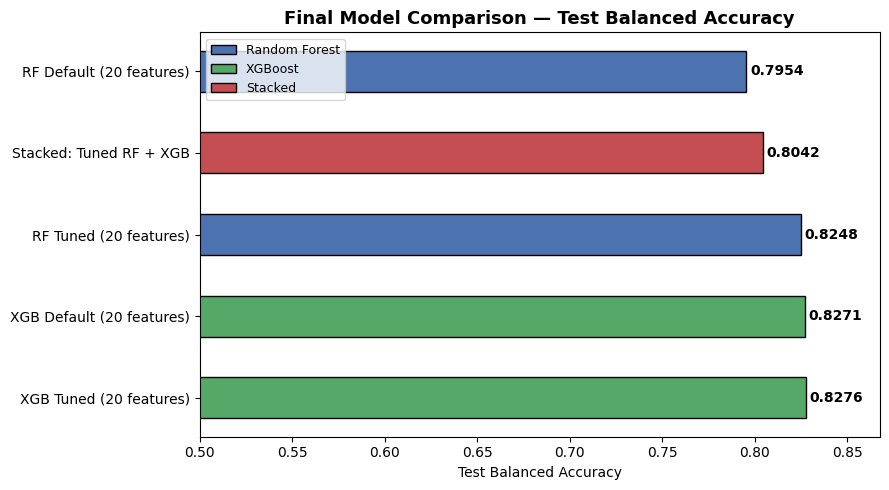

In [42]:
# --- Plot 1: Horizontal bar chart — Test Balanced Accuracy for all models ---
fig, ax = plt.subplots(figsize=(9, 5))

def _model_color(name):
    if 'Stacked' in name:
        return '#C44E52'
    elif 'XGB' in name:
        return '#55A868'
    else:
        return '#4C72B0'

colors = [_model_color(m) for m in results['Model']]
bars = ax.barh(results['Model'], results['Test Balanced Accuracy'],
               color=colors, edgecolor='black', height=0.5)

ax.set_xlabel('Test Balanced Accuracy')
ax.set_title('Final Model Comparison — Test Balanced Accuracy', fontsize=13, fontweight='bold')
ax.set_xlim(0.5, results['Test Balanced Accuracy'].max() + 0.04)

for bar, val in zip(bars, results['Test Balanced Accuracy']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', edgecolor='black', label='Random Forest'),
    Patch(facecolor='#55A868', edgecolor='black', label='XGBoost'),
    Patch(facecolor='#C44E52', edgecolor='black', label='Stacked')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 10. interpretation 

- Model fitting is going to be much better as we reduce features, starting from 377 is a lot of noise for our models to interpret so trying to reduce to keep only our best engineered features is going to improve model performance. 
- The features we choose to reduce were ones that etheir had very repetitive values and didnt give the model much imput or ones that were rare and did not need to be included to help the performance of the model. 
- stacking did not improve our models that much as we have already done a lot of tuning prior so building a metalearner just added noise. i would be curoius to see if the more models we add to the meta learner if that helps improve accuracy. 
- Tuning is still vital for model performance and should be something that we keep an eye on closely for whatever model were working on. 